In [3]:
print('Retail Order Analysis')

Retail Order Analysis


In [9]:
#import libraries
#!pip install kaggle pandas matplotlib seaborn

# Downloaded Dataset From Kaggle

In [24]:
import pandas as pd

df = pd.read_csv('orders.csv')
df['Ship Mode'].unique()


<StringArray>
[  'Second Class', 'Standard Class',  'Not Available',        'unknown',
    'First Class',              nan,       'Same Day']
Length: 7, dtype: str

# Data Cleaning

In [26]:
df.head()
# df.describe()

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [30]:
df.rename(columns={'Order Id':'order_id', 'City':'city'})
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')
df.head(5)

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [32]:

# deriving a  new columns discount , sale price and profit
df['discount']=df['list_price']*df['discount_percent']*.01
df['sale_price']= df['list_price']-df['discount']
df['profit']=df['sale_price']-df['cost_price']
df

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent,discount,sale_price,profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,5.2,254.8,14.8
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,21.9,708.1,108.1
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,0.5,9.5,-0.5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2,19.2,940.8,160.8
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5,1.0,19.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,2023-02-18,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,FUR-FU-10001889,30,30,3,4,1.2,28.8,-1.2
9990,9991,2023-03-17,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,FUR-FU-10000747,70,90,2,4,3.6,86.4,16.4
9991,9992,2022-08-07,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,TEC-PH-10003645,220,260,2,2,5.2,254.8,34.8
9992,9993,2022-11-19,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,OFF-PA-10004041,30,30,4,3,0.9,29.1,-0.9


In [33]:

#convert order date from object data type to datetime
df['order_date']=pd.to_datetime(df['order_date'],format="%Y-%m-%d")

In [34]:
df.info()

# Checking for NULL
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          9994 non-null   int64         
 1   order_date        9994 non-null   datetime64[us]
 2   ship_mode         9993 non-null   str           
 3   segment           9994 non-null   str           
 4   country           9994 non-null   str           
 5   city              9994 non-null   str           
 6   state             9994 non-null   str           
 7   postal_code       9994 non-null   int64         
 8   region            9994 non-null   str           
 9   category          9994 non-null   str           
 10  sub_category      9994 non-null   str           
 11  product_id        9994 non-null   str           
 12  cost_price        9994 non-null   int64         
 13  list_price        9994 non-null   int64         
 14  quantity          9994 non-null   i

order_id            0
order_date          0
ship_mode           1
segment             0
country             0
city                0
state               0
postal_code         0
region              0
category            0
sub_category        0
product_id          0
cost_price          0
list_price          0
quantity            0
discount_percent    0
discount            0
sale_price          0
profit              0
dtype: int64

In [35]:
# Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [36]:

#drop cost price list price and discount percent columns
df.drop(columns=['list_price','cost_price','discount_percent'],inplace=True)

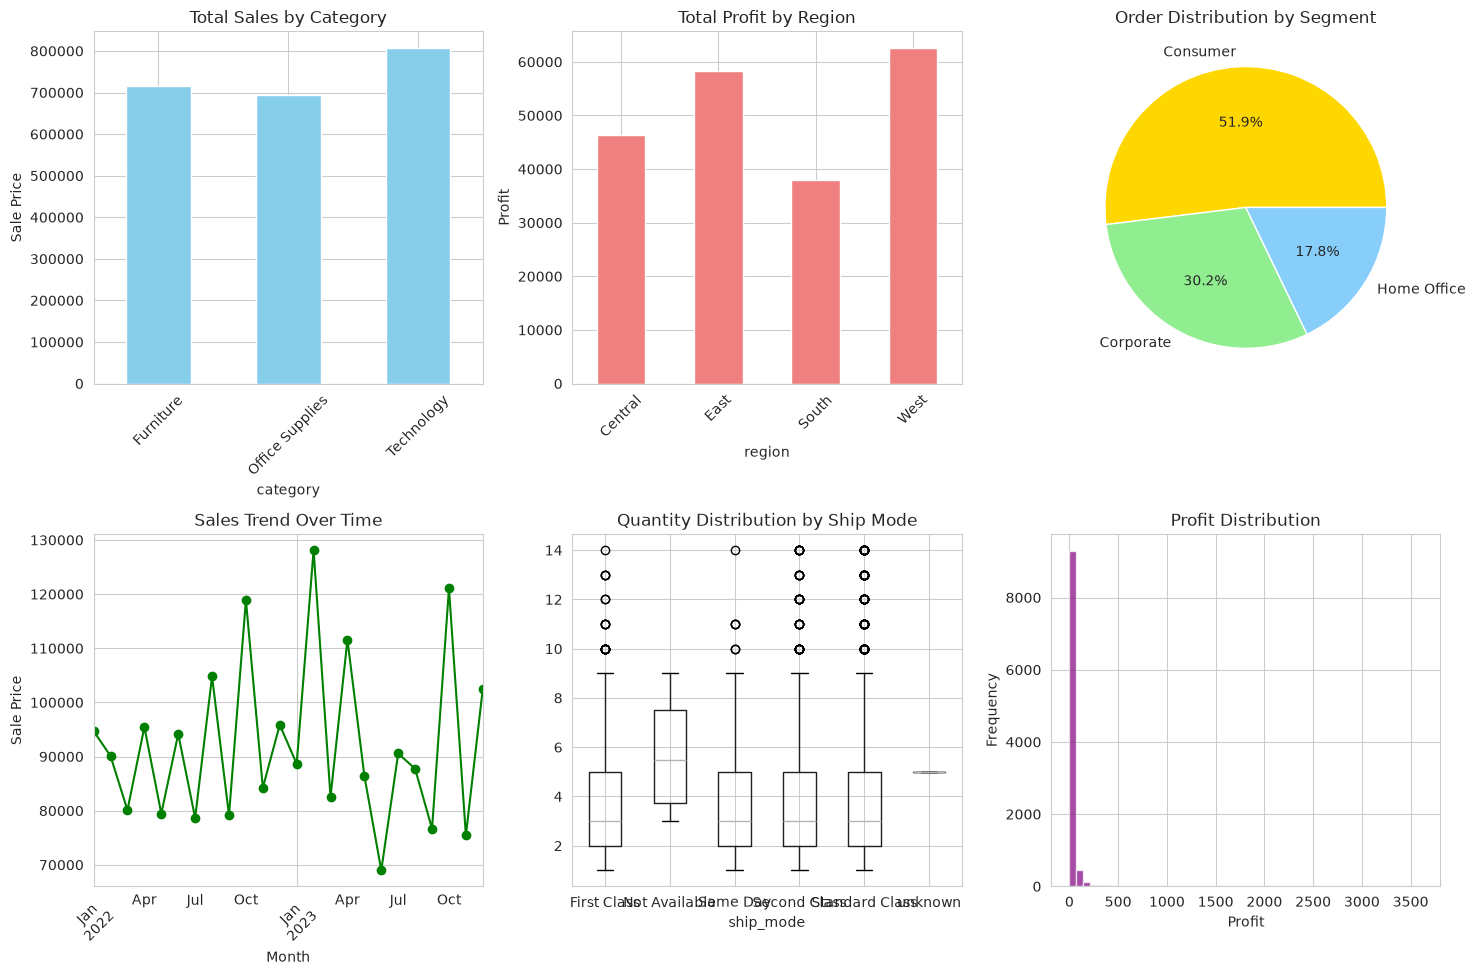

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

# 1. Sales by Category
plt.subplot(2, 3, 1)
df.groupby('category')['sale_price'].sum().plot(kind='bar', color='skyblue')
plt.title('Total Sales by Category')
plt.ylabel('Sale Price')
plt.xticks(rotation=45)

# 2. Profit by Region
plt.subplot(2, 3, 2)
df.groupby('region')['profit'].sum().plot(kind='bar', color='lightcoral')
plt.title('Total Profit by Region')
plt.ylabel('Profit')
plt.xticks(rotation=45)

# 3. Order Count by Segment
plt.subplot(2, 3, 3)
df['segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['gold', 'lightgreen', 'lightskyblue'])
plt.title('Order Distribution by Segment')
plt.ylabel('')

# 4. Sales Trend Over Time
plt.subplot(2, 3, 4)
df.groupby(df['order_date'].dt.to_period('M'))['sale_price'].sum().plot(kind='line', marker='o', color='green')
plt.title('Sales Trend Over Time')
plt.ylabel('Sale Price')
plt.xlabel('Month')
plt.xticks(rotation=45)

# 5. Quantity Distribution by Ship Mode
plt.subplot(2, 3, 5)
df.boxplot(column='quantity', by='ship_mode', ax=plt.gca())
plt.title('Quantity Distribution by Ship Mode')
plt.suptitle('')

# 6. Profit Distribution
plt.subplot(2, 3, 6)
plt.hist(df['profit'], bins=50, color='purple', alpha=0.7)
plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Loading Data into SQL Server

In [ ]:
import os
from getpass import getpass
from sqlalchemy import create_engine

# Connection info from env vars or prompt
PG_USER = os.getenv('PG_USER') or input("Postgres user: ")
PG_PASSWORD = os.getenv('PG_PASSWORD') or getpass("Postgres password: ")
PG_HOST = os.getenv('PG_HOST') or input("Postgres host [localhost]: ") or "localhost"
PG_PORT = os.getenv('PG_PORT') or input("Postgres port [5432]: ") or "5432"
PG_DB = os.getenv('PG_DB') or input("Postgres database: ")

engine = create_engine(f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}")

table_name = "orders_cleaned"  # change if desired
df.to_sql(table_name, engine, if_exists="replace", index=False, chunksize=1000, method="multi")

print(f"Wrote {len(df)} rows to table '{table_name}' in database '{PG_DB}' on {PG_HOST}:{PG_PORT}")


In [ ]:

# Also write to MySQL
MYSQL_USER = os.getenv('MYSQL_USER') or input("MySQL user: ")
MYSQL_PASSWORD = os.getenv('MYSQL_PASSWORD') or getpass("MySQL password: ")
MYSQL_HOST = os.getenv('MYSQL_HOST') or input("MySQL host [localhost]: ") or "localhost"
MYSQL_PORT = os.getenv('MYSQL_PORT') or input("MySQL port [3306]: ") or "3306"
MYSQL_DB = os.getenv('MYSQL_DB') or input("MySQL database: ")
mysql_table = table_name  # change if desired

# requires a MySQL DBAPI driver such as pymysql or mysqlconnector
mysql_engine = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}")

try:
    df.to_sql(mysql_table, mysql_engine, if_exists="replace", index=False, chunksize=1000, method="multi")
    print(f"Wrote {len(df)} rows to MySQL table '{mysql_table}' in database '{MYSQL_DB}' on {MYSQL_HOST}:{MYSQL_PORT}")
except Exception as e:
    print("Failed to write to MySQL:", e)